In [7]:
import sys
import os
from pathlib import Path

# Add the project root to python path so we can import src
# Assumes notebook is in 'quant-portfolio/notebooks/'
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# Enable auto-reloading so if you change data_manager.py, the notebook picks it up
%load_ext autoreload
%autoreload 2

print(f"Project Root: {project_root}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project Root: c:\Users\reymo\quant-portfolio


In [17]:
import yfinance as yf
import pandas as pd
from src.data_manager import DataManager

# 1. Initialize the DataManager
# We store data in a 'data/storage' folder at the project root
manager = DataManager(base_dir=project_root / "data" / "storage")

# 2. Download Real Data (using yfinance)
ticker = "NVDA"
print(f"Downloading {ticker}...")
# Let's get enough data to span multiple months to test partitioning
df_downloaded = yf.download(ticker, start="2023-10-01", end="2024-02-01", progress=False)

# Clean up yfinance multi-index columns if they exist (common yf annoyance)
if isinstance(df_downloaded.columns, pd.MultiIndex):
    df_downloaded.columns = df_downloaded.columns.get_level_values(0)

# 3. Save to Disk
print(f"Saving {len(df_downloaded)} rows...")
manager.save_ticker(ticker, df_downloaded)
print("Save successful!")

# 4. Load from Disk (The Moment of Truth)
print("Loading data back from storage...")
df_loaded = manager.load_ticker(ticker)

# 5. Verification
print(f"\nLoaded {len(df_loaded)} rows.")
print(f"Head of data:\n{df_loaded.head(3)}")
print(f"\nTail of data:\n{df_loaded.tail(3)}")

# Quick sanity check
if len(df_loaded) == len(df_downloaded):
    print("\n✅ SUCCESS: Row counts match!")
else:
    print(f"\n⚠️ WARNING: Row count mismatch. Downloaded: {len(df_downloaded)}, Loaded: {len(df_loaded)}")

C:\Users\reymo\AppData\Local\Temp\ipykernel_26832\1724495193.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_downloaded = yf.download(ticker, start="2023-10-01", end="2024-02-01", progress=False)


Saving 84 rows...
Save successful!
Loading data back from storage...

Loaded 84 rows.
Head of data:
Price           Close       High        Low       Open     Volume  year month
Date                                                                         
2023-10-02  44.753128  45.145872  43.832720  44.001610  433298000  2023    10
2023-10-03  43.488945  45.100908  43.218120  44.779113  470850000  2023    10
2023-10-04  44.012611  44.114547  43.264094  43.713804  361821000  2023    10

Tail of data:
Price           Close       High        Low       Open     Volume  year month
Date                                                                         
2024-01-29  62.430218  62.454203  60.873087  61.197903  348733000  2024     1
2024-01-30  62.739040  63.457642  62.225327  62.864973  410735000  2024     1
2024-01-31  61.492744  62.234332  60.666205  61.405791  453795000  2024     1

✅ SUCCESS: Row counts match!


## 3. Mathematical Feature Engineering

### Why Log Returns?
We use **Log Returns** ($r_t$) instead of Simple Returns ($R_t$) for two main reasons:

1.  **Time Additivity:** Log returns can be summed over time to get the total return.
    $$r_{total} = \sum r_i$$
    (Simple returns require geometric multiplication, which is harder to model).
2.  **Statistical Properties:** Log returns are unbounded $(-\infty, \infty)$, whereas simple returns are bounded at -100%. This makes log returns closer to a Normal Distribution, simplifying future modeling.

**Formula:**
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [13]:
import numpy as np

# Create a working copy so we don't mess up the original loaded dataframe
df = df_loaded.copy()

# ---------------------------------------------------------
# 1. Determine which column to use
# ---------------------------------------------------------
# 'Adj Close' accounts for dividends/splits. Prefer it if available.
price_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
print(f"Using column: {price_col}")

# ---------------------------------------------------------
# 2. Calculate Log Returns
# ---------------------------------------------------------
# Formula: r_t = ln(P_t) - ln(P_{t-1})
df['log_ret'] = np.log(df[price_col] / df[price_col].shift(1))

# ---------------------------------------------------------
# 3. Calculate Rolling Volatility (21-day window)
# ---------------------------------------------------------
# We use a 21-day window (approx 1 trading month).
# We multiply by sqrt(252) to "annualize" the daily standard deviation.
df['volatility_21d'] = df['log_ret'].rolling(window=21).std() * np.sqrt(252)

# ---------------------------------------------------------
# 4. Cleanup
# ---------------------------------------------------------
# The first row will be NaN (due to shift).
# The first 20 rows of volatility will be NaN (due to rolling window).
df.dropna(inplace=True)

print("Feature Engineering Complete.")
print(df[['log_ret', 'volatility_21d']].describe())

Using column: Close
Feature Engineering Complete.
Price    log_ret  volatility_21d
count  42.000000       42.000000
mean    0.004405        0.337349
std     0.018000        0.058904
min    -0.030561        0.276343
25%    -0.009142        0.290557
50%     0.006264        0.304470
75%     0.019032        0.397824
max     0.037186        0.439299


<>:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:31: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\reymo\AppData\Local\Temp\ipykernel_26832\1685335288.py:31: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].plot(x, p, 'r', linewidth=2, label=f'Normal Dist ($\mu$={mu:.4f}, $\sigma$={std:.4f})')
C:\Users\reymo\AppData\Local\Temp\ipykernel_26832\1685335288.py:31: Syn

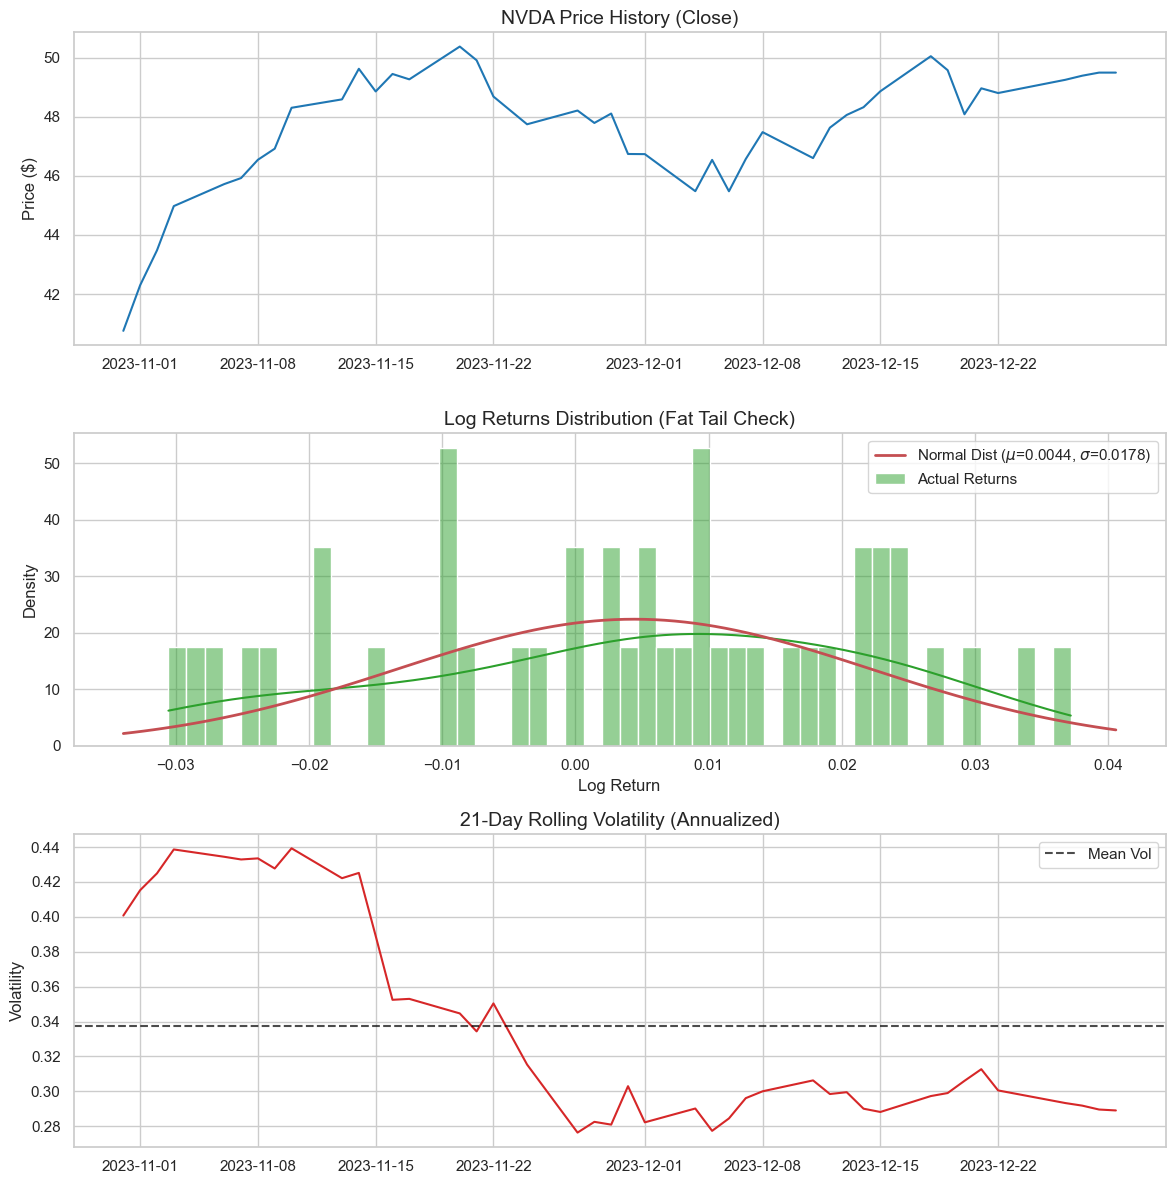

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Aesthetic settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 12] # Taller figure to stack 3 plots

# Create a figure with 3 subplots
fig, axes = plt.subplots(3, 1, sharex=False)

# ---------------------------------------------------------
# Plot 1: Price History
# ---------------------------------------------------------
axes[0].plot(df.index, df[price_col], color='#1f77b4', linewidth=1.5)
axes[0].set_title(f'{ticker} Price History ({price_col})', fontsize=14)
axes[0].set_ylabel('Price ($)')

# ---------------------------------------------------------
# Plot 2: Returns Distribution vs Normal Distribution
# ---------------------------------------------------------
# The Histogram of our actual data
sns.histplot(df['log_ret'], bins=50, kde=True, ax=axes[1],
             color='#2ca02c', stat="density", label='Actual Returns')

# The Theoretical Normal Distribution (Red Line)
mu, std = norm.fit(df['log_ret'])
xmin, xmax = axes[1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axes[1].plot(x, p, 'r', linewidth=2, label=f'Normal Dist ($\mu$={mu:.4f}, $\sigma$={std:.4f})')

axes[1].legend()
axes[1].set_title('Log Returns Distribution (Fat Tail Check)', fontsize=14)
axes[1].set_xlabel('Log Return')

# ---------------------------------------------------------
# Plot 3: Volatility Regimes
# ---------------------------------------------------------
axes[2].plot(df.index, df['volatility_21d'], color='#d62728', linewidth=1.5)
axes[2].axhline(df['volatility_21d'].mean(), color='black', linestyle='--', alpha=0.7, label='Mean Vol')
axes[2].set_title('21-Day Rolling Volatility (Annualized)', fontsize=14)
axes[2].set_ylabel('Volatility')
axes[2].legend()

plt.tight_layout()
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

def test_stationarity(timeseries, name="Series"):
    print(f"--- ADF Test for {name} ---")
    result = adfuller(timeseries.dropna())
    adf_stat = result[0]
    p_value = result[1]
    
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value:       {p_value:.4e}")
    
    # Critical values
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"\t{key}: {value:.4f}")
        
    if p_value < 0.05:
        print(f"✅ Result: {name} is STATIONARY (Reject Null Hypothesis)")
    else:
        print(f"❌ Result: {name} is NON-STATIONARY (Fail to Reject H0)")
    print("")

# Test 1: Raw Prices (Expect Non-Stationary)
test_stationarity(df[price_col], "Raw Prices")

# Test 2: Log Returns (Expect Stationary)
test_stationarity(df['log_ret'], "Log Returns")

--- ADF Test for Raw Prices ---
ADF Statistic: -3.7704
p-value:       3.2255e-03
Critical Values:
	1%: -3.6010
	5%: -2.9351
	10%: -2.6060
✅ Result: Raw Prices is STATIONARY (Reject Null Hypothesis)

--- ADF Test for Log Returns ---
ADF Statistic: -6.5701
p-value:       7.9757e-09
Critical Values:
	1%: -3.6010
	5%: -2.9351
	10%: -2.6060
✅ Result: Log Returns is STATIONARY (Reject Null Hypothesis)



In [16]:
# ---------------------------------------------------------
# Long-Run Stationarity Check (5 Years)
# ---------------------------------------------------------
print("Downloading 5 years of data for verification...")
df_long = yf.download(ticker, start="2019-01-01", end="2024-01-01", progress=False)

# Cleanup MultiIndex if present
if isinstance(df_long.columns, pd.MultiIndex):
    df_long.columns = df_long.columns.get_level_values(0)

price_col_long = 'Adj Close' if 'Adj Close' in df_long.columns else 'Close'

print(f"\n--- Re-testing Stationarity over 5 Years ({len(df_long)} rows) ---")
# reusing your test_stationarity function from Cell 5
test_stationarity(df_long[price_col_long], "Long-Term Raw Prices")

C:\Users\reymo\AppData\Local\Temp\ipykernel_26832\948091144.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_long = yf.download(ticker, start="2019-01-01", end="2024-01-01", progress=False)



--- Re-testing Stationarity over 5 Years (1258 rows) ---
--- ADF Test for Long-Term Raw Prices ---
ADF Statistic: 0.8006
p-value:       9.9165e-01
Critical Values:
	1%: -3.4356
	5%: -2.8639
	10%: -2.5680
❌ Result: Long-Term Raw Prices is NON-STATIONARY (Fail to Reject H0)

